[2026-07-12 02:39:20] [info     ] 因子形状: (117000, 3)
        date instrument    factor
0 2024-01-02  000006.SZ  0.275914
1 2024-01-02  000012.SZ  0.184730
2 2024-01-02  000016.SZ  0.296826
3 2024-01-02  000019.SZ  0.148516
4 2024-01-02  000025.SZ  0.182866
5 2024-01-02  000028.SZ  0.044585
6 2024-01-02  000029.SZ  0.252921
7 2024-01-02  000030.SZ  0.132120
8 2024-01-02  000032.SZ -4.677188
9 2024-01-02  000034.SZ  0.198917
缺失值数量: 0  ← 应为0
重复行数: 0  ← 应为0
[2026-07-12 02:39:20] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-12 02:39:21] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-12 02:39:21] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-07-12 02:39:22] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-06-28
[2026-07-12 02:39:22] [info     ] ========== 数据检查 ==========
[2026-07-12 02:39:22] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio',

时段,IC
2024-01-15~2024-02-08,-0.0191

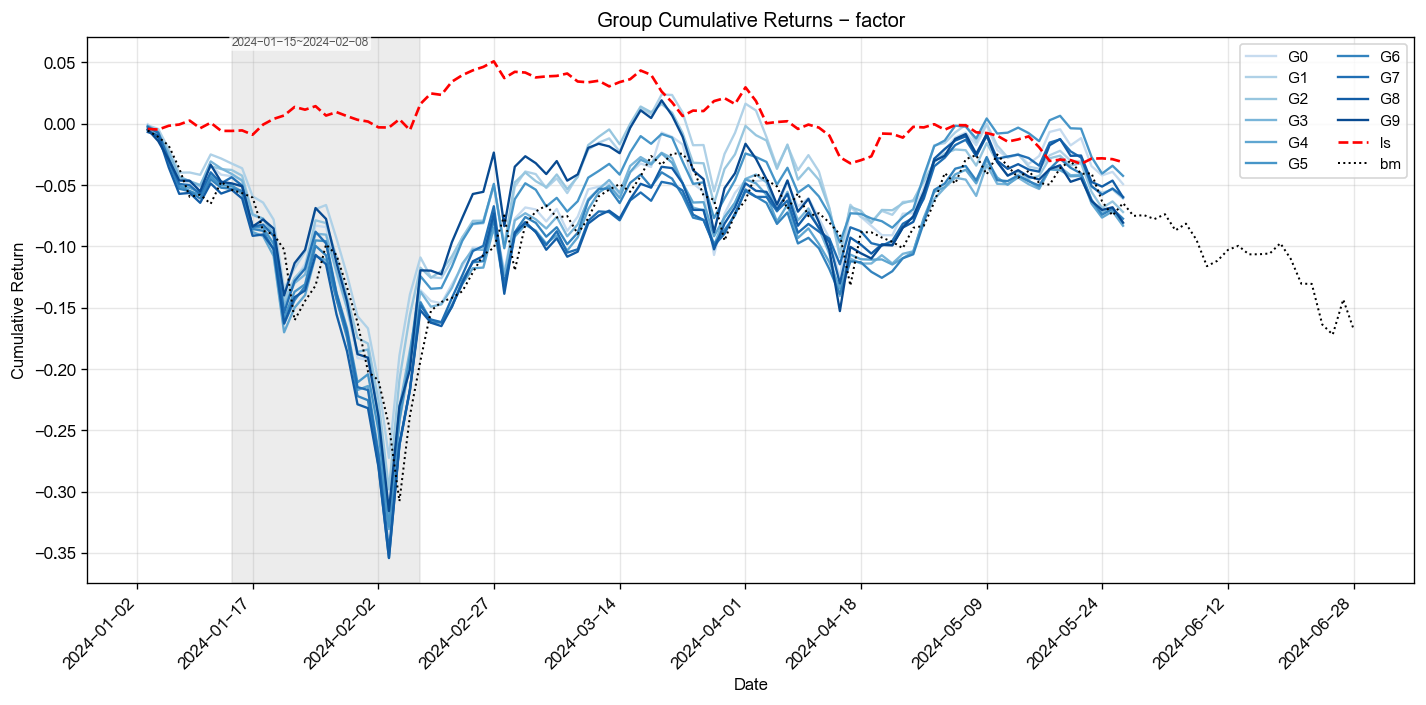
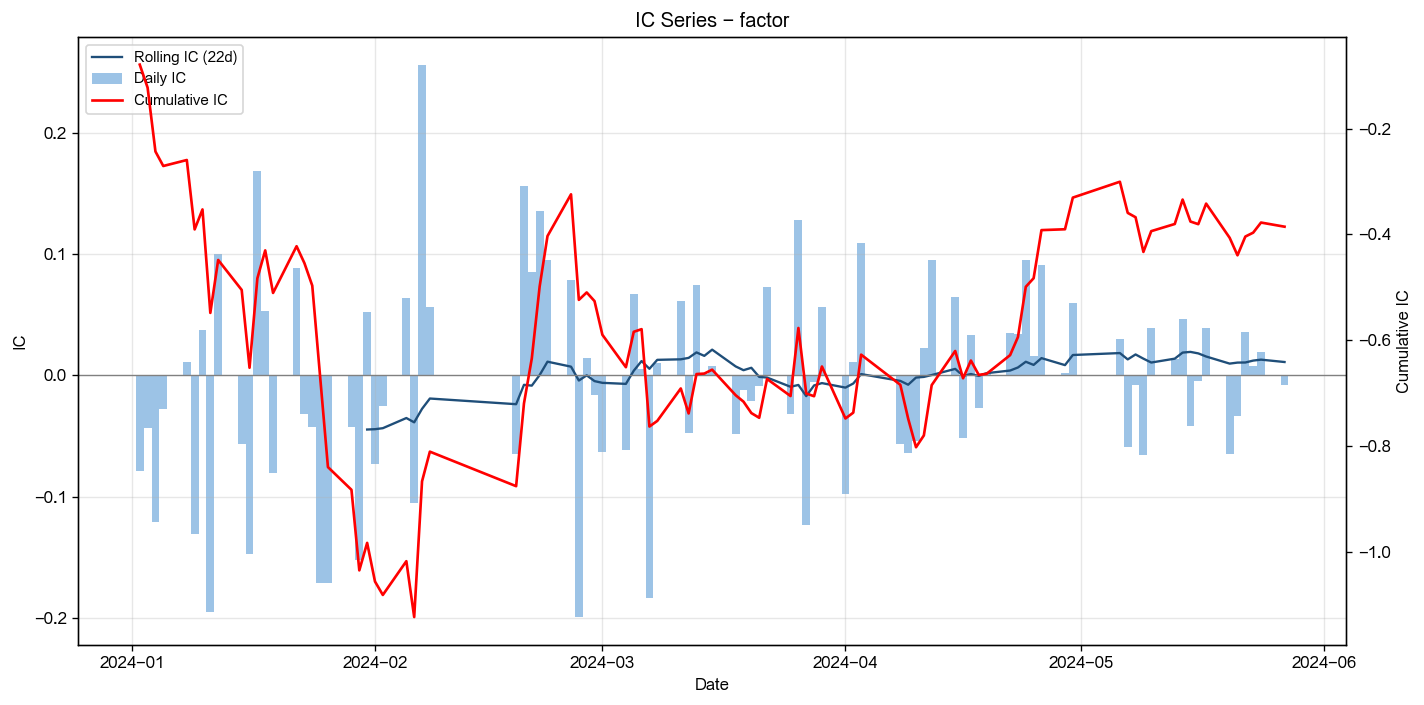
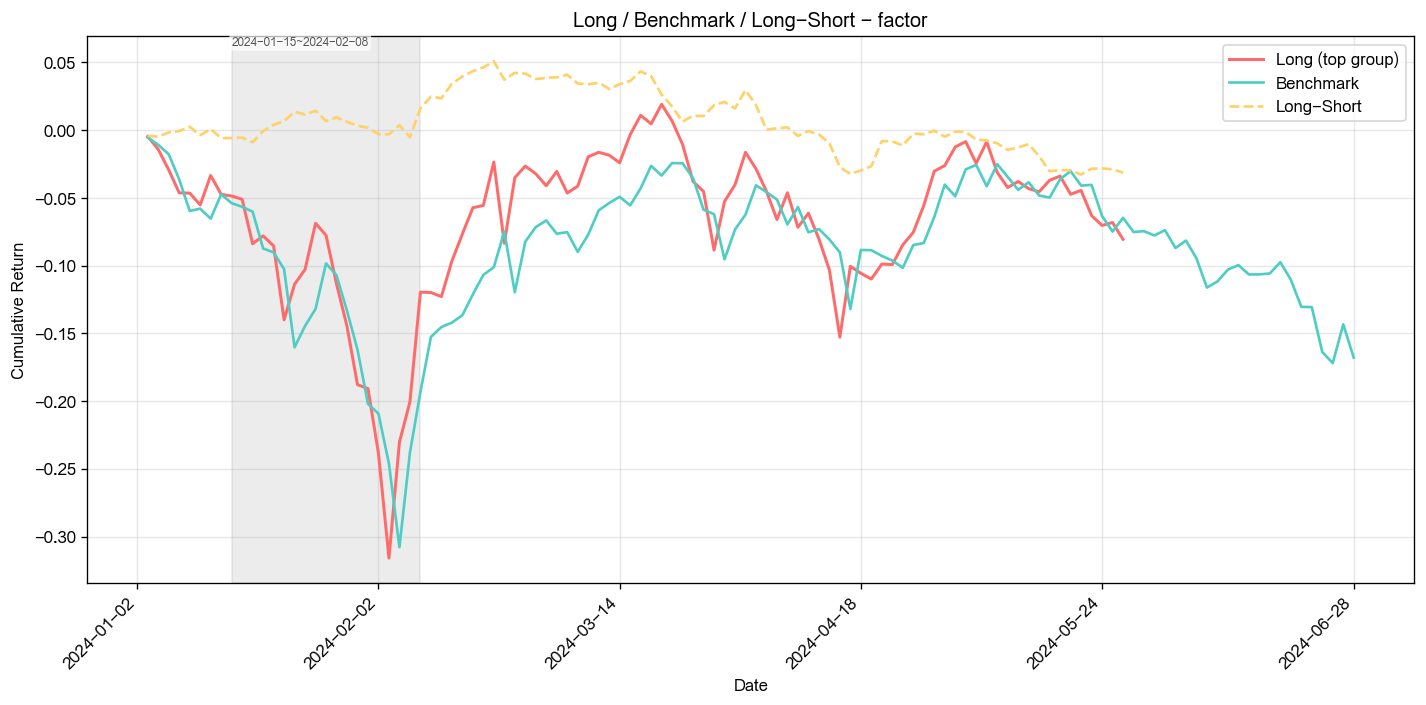
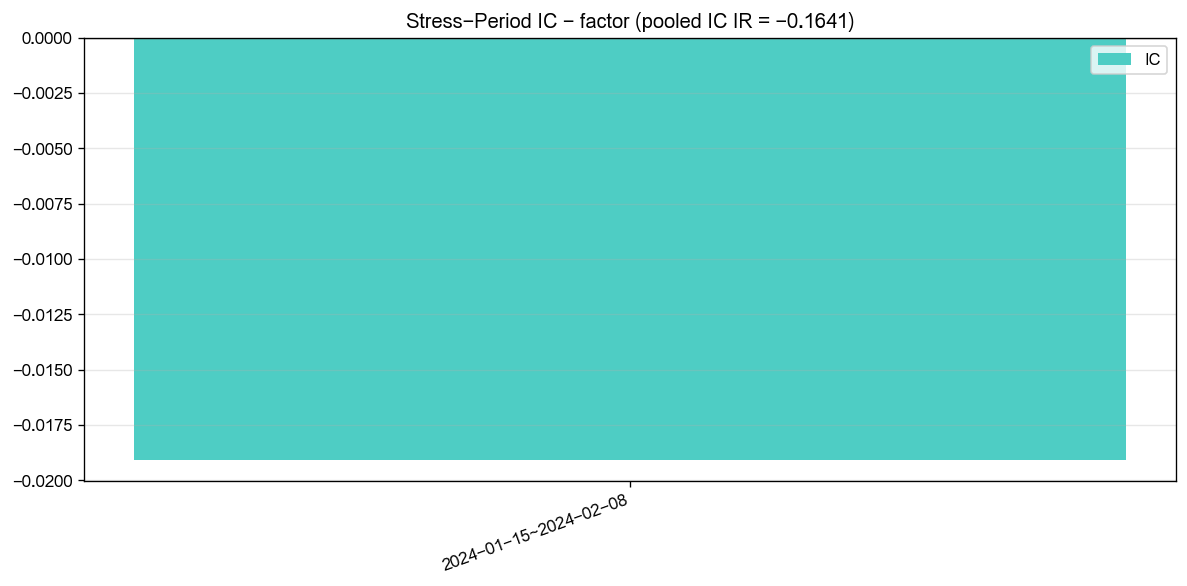
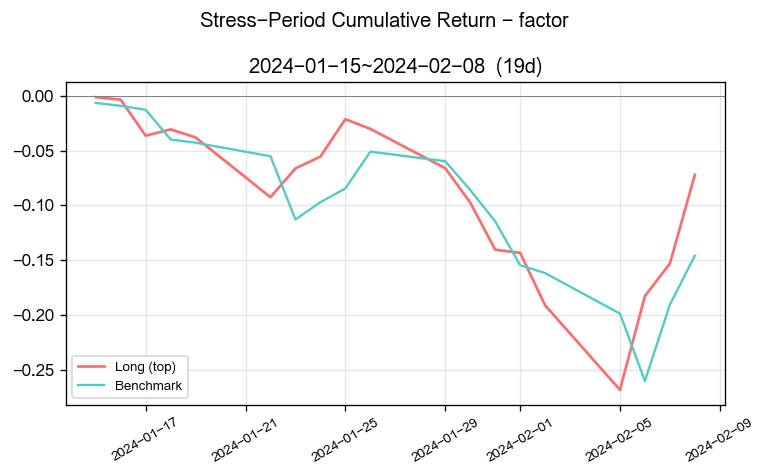

[2026-07-12 02:39:26] [info     ] ========== 因子池回归 ==========
[2026-07-12 02:39:26] [info     ] 加载 T+1 收益数据完成                  end_date=2024-06-28 instrument_count=1103 rows=138298 start_date=2024-01-02
[2026-07-12 02:39:26] [info     ] 获取收益率数据, 耗时: 0.2881 秒
[2026-07-12 02:39:27] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.0879 秒
[2026-07-12 02:39:27] [info     ] 统计 回归结果, 耗时: 0.0937 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,factor,4.6708,0.0042,0.0009,1.0000
2,gross_profit_rate_ttm,4.5214,0.0113,0.0025,1.0000
3,kdj_d_9_3_3,3.4568,0.0164,0.0047,1.0000
4,net_profit_rate_ttm,3.0375,0.0061,0.0020,1.0000
5,macd_dea_12_26_9,2.6511,0.0091,0.0034,1.0000
6,roa_avg_ttm,2.3148,0.0217,0.0094,1.0000
7,pe_ttm,2.2993,0.0012,0.0005,1.0000
8,netflow_amount_main,2.1498,0.0358,0.0167,1.0000
9,net_active_buy_amount_main,1.8945,0.0189,0.0100,1.0000
10,rsi_12,1.8940,0.0521,0.0275,1.0000

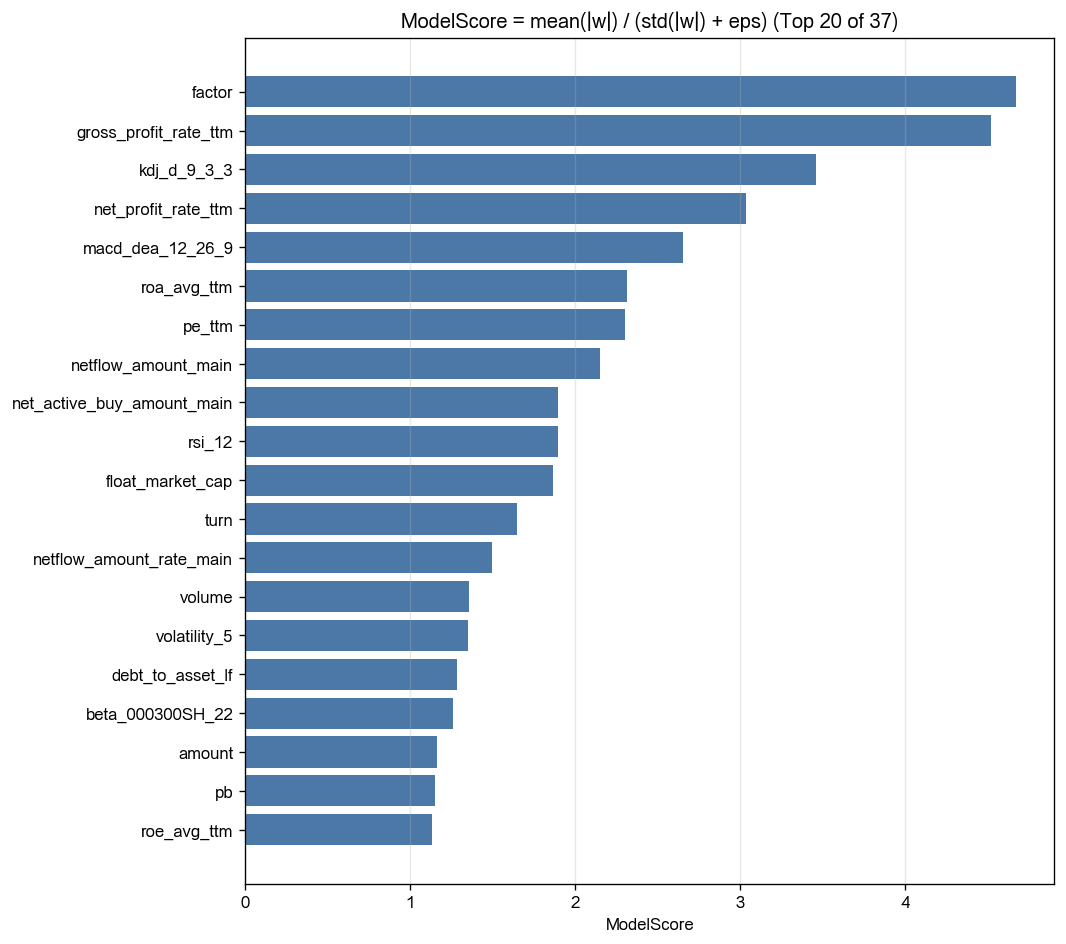
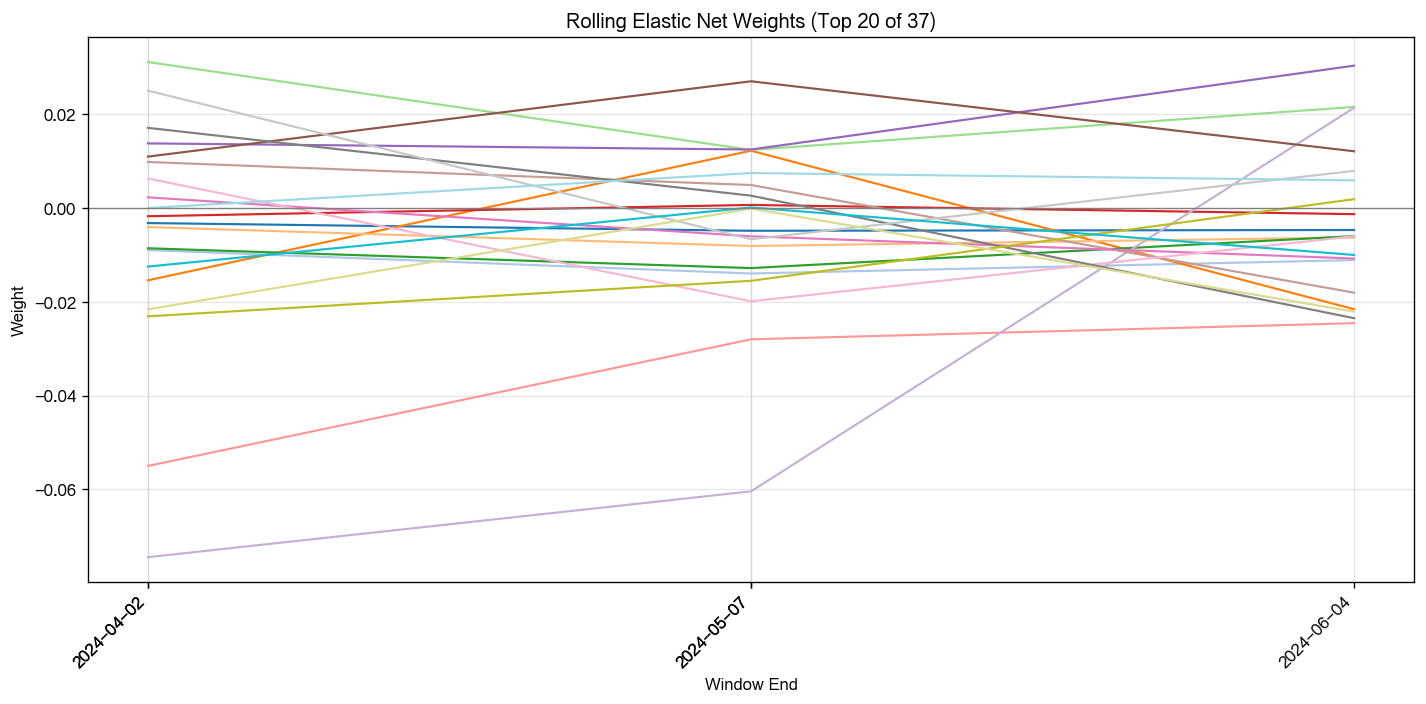
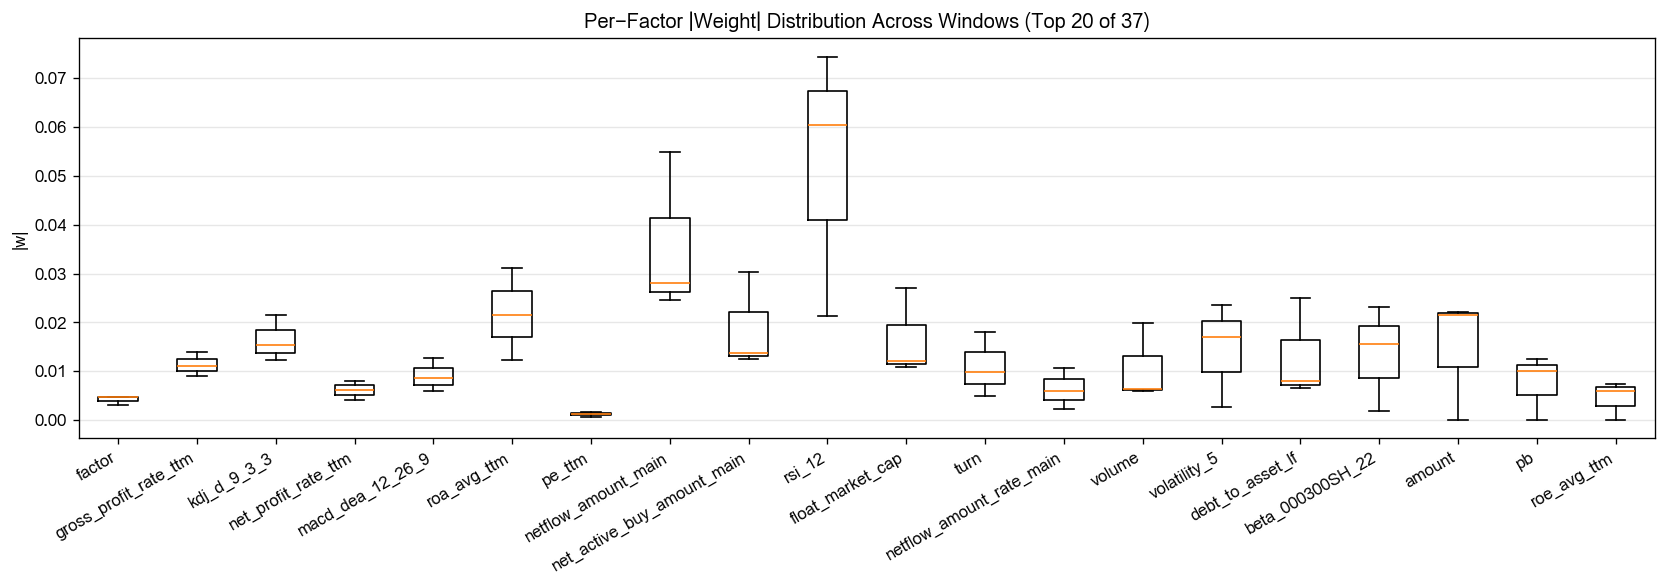
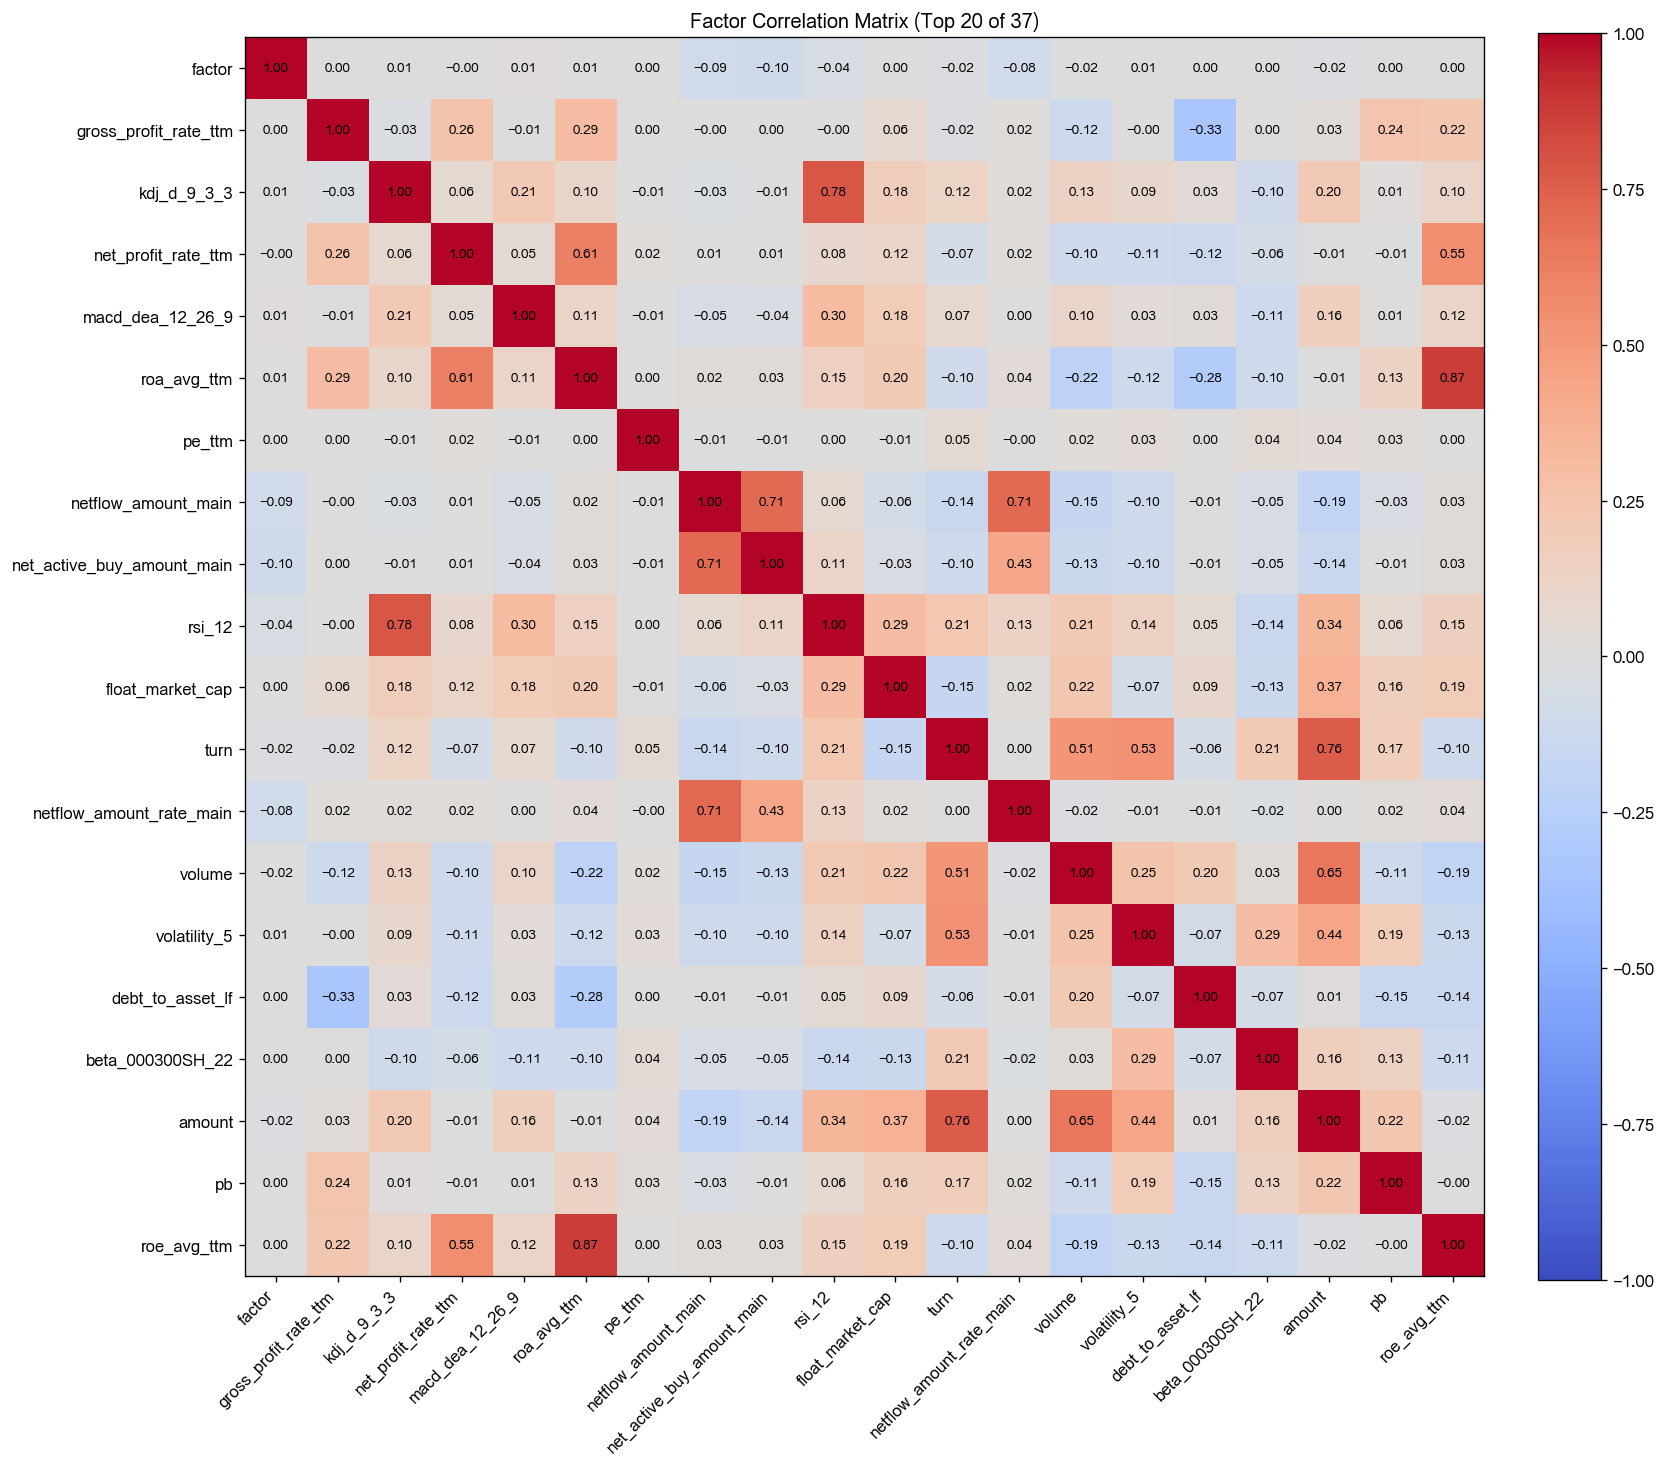

[2026-07-12 02:39:28] [warning  ] 返回的Outputs实例(size=16725389) 大于 64K, 将不会被缓存
[2026-07-12 02:39:28] [info     ] bigalpha_eval.v4 运行完成 [6.430s].
{'raw_factor':              date instrument    factor
0      2024-01-02  000006.SZ  0.275914
1      2024-01-02  000012.SZ  0.184730
2      2024-01-02  000016.SZ  0.296826
3      2024-01-02  000019.SZ  0.148516
4      2024-01-02  000025.SZ  0.182866
...           ...        ...       ...
116995 2024-06-28  688739.SH  0.265698
116996 2024-06-28  688776.SH  0.308816
116997 2024-06-28  688789.SH  0.232713
116998 2024-06-28  688798.SH  0.257706
116999 2024-06-28  688800.SH  0.190382

[117000 rows x 3 columns], 'process_factor':              date instrument    factor
0      2024-01-02  000006.SZ  0.520158
1      2024-01-02  000012.SZ  0.525553
2      2024-01-02  000016.SZ  0.921985
3      2024-01-02  000019.SZ  0.473030
4      2024-01-02  000025.SZ  1.235365
...           ...        ...       ...
116995 2024-06-28  688739.SH  0.157402
116996 2024-06-2

In [4]:
import warnings
from typing import Dict, Optional
import numpy as np
import pandas as pd
import dai

warnings.filterwarnings("ignore")


def load_daily_ohlcv(
    datasources: Dict[str, str],
    start_date: str,
    end_date: str,
    lookback_days: int = 60,
) -> pd.DataFrame:
    bar1m = datasources["bar1m"]
    query_start = (pd.to_datetime(start_date) - pd.Timedelta(days=lookback_days)).strftime(
        "%Y-%m-%d %H:%M:%S"
    )

    sql = f"""
    SELECT
        CAST(date_trunc('day', date) AS DATETIME) AS date,
        instrument,
        first(open ORDER BY date) AS open,
        max(high) AS high,
        min(low) AS low,
        last(close ORDER BY date) AS close,
        sum(volume) AS volume,
        sum(amount) AS amount
    FROM {bar1m}
    WHERE date >= '{query_start}' AND date <= '{end_date}'
    GROUP BY date, instrument
    """
    df = dai.query(sql).df()
    df["date"] = pd.to_datetime(df["date"])
    df = df.drop_duplicates(["date", "instrument"])
    return df


def compute_reversal_reliability(daily: pd.DataFrame, window: int = 20) -> pd.DataFrame:
    daily = daily.sort_values(["instrument", "date"])
    daily["ret"] = daily.groupby("instrument")["close"].pct_change()
    daily["up"] = (daily["ret"] > 0.001).astype(int)
    daily["down"] = (daily["ret"] < -0.001).astype(int)
    daily["next_down"] = daily.groupby("instrument")["down"].shift(-1).fillna(0).astype(int)

    def rolling_prob(group):
        up = group["up"].astype(int)
        next_down = group["next_down"].astype(int)
        up_count = up.rolling(window, min_periods=int(window*0.5)).sum()
        up_and_down = (up & next_down).rolling(window, min_periods=int(window*0.5)).sum()
        prob = up_and_down / (up_count + 1e-8)
        return prob

    daily["reliability"] = daily.groupby("instrument", group_keys=False).apply(
        lambda g: rolling_prob(g)
    ).reset_index(level=0, drop=True)
    daily["reliability"] = daily["reliability"].fillna(0)
    daily = daily.drop_duplicates(["date", "instrument"])
    return daily


def get_market_state(daily: pd.DataFrame, vol_mult: float = 1.0) -> pd.Series:
    market_ret = daily.groupby("date")["ret"].mean()
    market_ret_abs_20 = market_ret.rolling(20).apply(lambda x: abs(x).mean())
    market_vol_20 = market_ret.rolling(20).std()
    med_ret_abs = market_ret_abs_20.rolling(60).median()
    med_vol = market_vol_20.rolling(60).median()
    is_osc = (market_ret_abs_20 < med_ret_abs) & (market_vol_20 < med_vol * vol_mult)
    is_osc = is_osc.fillna(False)
    return is_osc


def generate_reversal_factor(
    datasources: Dict[str, str],
    start_date: str,
    end_date: str,
    lookback_days: int = 60,
    window_reliability: int = 20,
    top_ratio: float = 0.3,
    vol_mult: float = 1.0,
    non_osc_weight: float = 0.05,
    trend_window: int = 20,
    trend_threshold: float = 0.6,
    trend_factor_weight: float = 1.0,
) -> pd.DataFrame:
    daily = load_daily_ohlcv(datasources, start_date, end_date, lookback_days)
    if daily.empty:
        return pd.DataFrame(columns=["date", "instrument", "factor"])

    daily = compute_reversal_reliability(daily, window=window_reliability)
    daily = daily.drop_duplicates(["date", "instrument"])

    # ---------- 个股级趋势判断 ----------
    # 上涨日比例（滚动窗口）
    daily["up_flag"] = (daily["ret"] > 0.001).astype(int)
    def rolling_up_ratio(group):
        return group["up_flag"].rolling(trend_window, min_periods=int(trend_window*0.5)).mean()
    daily["up_ratio"] = daily.groupby("instrument", group_keys=False).apply(
        lambda g: rolling_up_ratio(g)
    ).reset_index(level=0, drop=True)
    daily["up_ratio"] = daily["up_ratio"].fillna(0)
    daily["is_trend"] = daily["up_ratio"] >= trend_threshold

    # 趋势因子：过去 trend_window 日的累计收益
    daily["ret_trend"] = daily.groupby("instrument")["close"].pct_change(periods=trend_window)

    # ---------- 市场整体状态 ----------
    is_osc_series = get_market_state(daily, vol_mult=vol_mult)
    daily["is_osc"] = daily["date"].map(is_osc_series).fillna(False)

    # 反转可靠性排名（横截面）
    daily["reliability_rank"] = daily.groupby("date")["reliability"].rank(pct=True)
    daily["is_high_rel"] = daily["reliability_rank"] > (1 - top_ratio)

    # ---------- 因子赋值 ----------
    daily["factor"] = 0.0

    # 基础反转（所有股票，权重 small）
    daily["factor"] = -daily["ret"] * non_osc_weight

    # 震荡市 + 高可靠性 -> 强化反转（全权重）
    mask_osc_strong = daily["is_osc"] & daily["is_high_rel"]
    daily.loc[mask_osc_strong, "factor"] = -daily.loc[mask_osc_strong, "ret"]

    # 非震荡市 + 趋势股 -> 切换为趋势因子
    mask_trend = (~daily["is_osc"]) & daily["is_trend"]
    daily.loc[mask_trend, "factor"] = daily.loc[mask_trend, "ret_trend"] * trend_factor_weight

    # 非震荡市 + 非趋势股 -> 仅保留基础反转（已赋值）

    # ---------- 过滤目标日期 ----------
    start_ts = pd.to_datetime(start_date)
    end_ts = pd.to_datetime(end_date)
    daily = daily[(daily["date"] >= start_ts) & (daily["date"] <= end_ts)]
    daily = daily.drop_duplicates(["date", "instrument"])

    if daily.empty:
        return pd.DataFrame(columns=["date", "instrument", "factor"])

    # ---------- 截面标准化 ----------
    def cross_sectional_zscore(x):
        x = x.replace([np.inf, -np.inf], np.nan)
        if x.notna().sum() < 10:
            return pd.Series(np.nan, index=x.index)
        lower = x.quantile(0.01)
        upper = x.quantile(0.99)
        x = x.clip(lower, upper)
        std = x.std()
        if pd.isna(std) or std < 1e-12:
            return pd.Series(np.nan, index=x.index)
        return (x - x.mean()) / std

    daily["factor"] = daily.groupby("date")["factor"].transform(cross_sectional_zscore)
    daily["factor"] = daily["factor"].fillna(0.0)
    daily = daily.drop_duplicates(["date", "instrument"])

    # ---------- 合并完整股票池（确保无缺失） ----------
    pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={"date": [start_date, end_date]},
    ).df()
    pool["date"] = pd.to_datetime(pool["date"])
    pool = pool.drop_duplicates(["date", "instrument"])

    result = pool.merge(
        daily[["date", "instrument", "factor"]],
        on=["date", "instrument"],
        how="left",
    )
    result["factor"] = result["factor"].fillna(0.0)
    result = result.drop_duplicates(["date", "instrument"])

    return result[["date", "instrument", "factor"]].sort_values(["date", "instrument"]).reset_index(drop=True)


def main(datasources, start_date, end_date):
    # 参数可调，以适配不同市场环境
    return generate_reversal_factor(
        datasources, start_date, end_date,
        top_ratio=0.4,                # 高可靠性股票比例
        vol_mult=1.5,                 # 波动率乘数（越大震荡市越多）
        non_osc_weight=0.05,          # 非震荡市基础反转权重（防止完全无信号）
        trend_window=20,              # 趋势判断窗口
        trend_threshold=0.6,          # 上涨日比例阈值（>=0.6 视为趋势股）
        trend_factor_weight=1.0       # 趋势因子权重
    )


if __name__ == '__main__':
    from bigmodule import M
    import structlog
    logger = structlog.get_logger()

    datasources = {'bar1m': 'bigalpha_2026_stock_bar1m'}
    start_date = '2024-01-01 00:00:00'
    end_date = '2024-06-30 23:59:59'

    factor_data = main(datasources, start_date, end_date)
    logger.info(f"因子形状: {factor_data.shape}")
    print(factor_data.head(10))

    missing = factor_data['factor'].isna().sum()
    dup = factor_data.duplicated(subset=['date', 'instrument']).sum()
    print(f"缺失值数量: {missing}  ← 应为0")
    print(f"重复行数: {dup}  ← 应为0")

    # 评估
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()
    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )
    print(result)